# EuroSAT RGB Exploratory Data Analysis

This notebook analyzes the EuroSAT RGB image dataset at `/home/pannatat/personal/eurosat-multispectral-classification-mlops/data/raw/EuroSAT_RGB/2750`.

It ignores `Zone.Identifier` sidecar files and only uses real `.jpg` images.

In [14]:
from pathlib import Path
from collections import defaultdict
import hashlib
import os
import random

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageFilter, UnidentifiedImageError
from sklearn.model_selection import train_test_split

DATA_DIR = Path('/home/pannatat/personal/eurosat-multispectral-classification-mlops/data/raw/EuroSAT_RGB/2750')
RANDOM_STATE = 42
EXPECTED_SIZE = (64, 64)

plt.style.use('seaborn-v0_8-whitegrid')
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

assert DATA_DIR.exists(), f'Dataset directory not found: {DATA_DIR}'

## 1. Dataset Structure

Check class folders, count JPG images, and ignore `Zone.Identifier` files.

In [15]:
class_dirs = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])
classes = [p.name for p in class_dirs]

zone_identifier_files = [p for p in DATA_DIR.rglob('*') if 'Zone.Identifier' in p.name]
image_paths = sorted([
    p for p in DATA_DIR.rglob('*.jpg')
    if p.is_file() and 'Zone.Identifier' not in p.name
])

print(f'Dataset directory: {DATA_DIR}')
print(f'Number of class folders: {len(classes)}')
print(classes)
print(f'Number of JPG images, excluding Zone.Identifier files: {len(image_paths):,}')
print(f'Ignored Zone.Identifier files: {len(zone_identifier_files):,}')

assert len(classes) == 10, f'Expected 10 class folders, found {len(classes)}'

Dataset directory: /home/pannatat/personal/eurosat-multispectral-classification-mlops/data/raw/EuroSAT_RGB/2750
Number of class folders: 10
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of JPG images, excluding Zone.Identifier files: 27,000
Ignored Zone.Identifier files: 27,000


## 2. Class Distribution

Count images in each class, display a bar chart, and check whether the classes are balanced.

,class,image_count
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


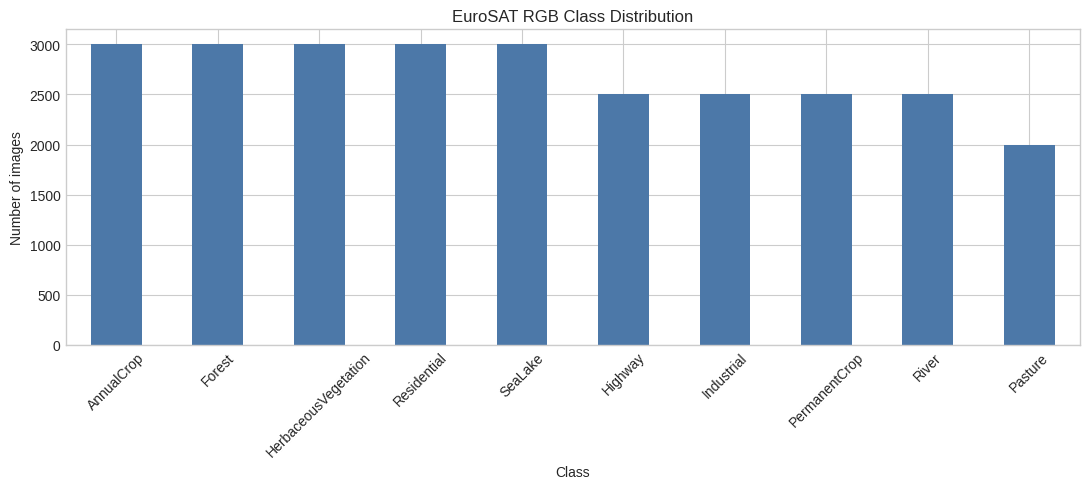

Min class count: 2,000
Max class count: 3,000
Imbalance ratio max/min: 1.50
Classes are not perfectly balanced. Use stratified splitting and consider class weights if needed.


In [16]:
records = [{'path': path, 'class': path.parent.name, 'filename': path.name} for path in image_paths]
df = pd.DataFrame(records)
class_counts = df['class'].value_counts().sort_index()
class_summary = class_counts.rename_axis('class').reset_index(name='image_count')
display(class_summary)

fig, ax = plt.subplots(figsize=(11, 5))
class_counts.sort_values(ascending=False).plot(kind='bar', ax=ax, color='#4C78A8')
ax.set_title('EuroSAT RGB Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Number of images')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f'Min class count: {class_counts.min():,}')
print(f'Max class count: {class_counts.max():,}')
print(f'Imbalance ratio max/min: {imbalance_ratio:.2f}')
print('Classes are approximately balanced.' if imbalance_ratio <= 1.10 else 'Classes are not perfectly balanced. Use stratified splitting and consider class weights if needed.')

## 3. Example Images

Show several images from every class. Then compare visually confusing classes such as `AnnualCrop` and `PermanentCrop`.

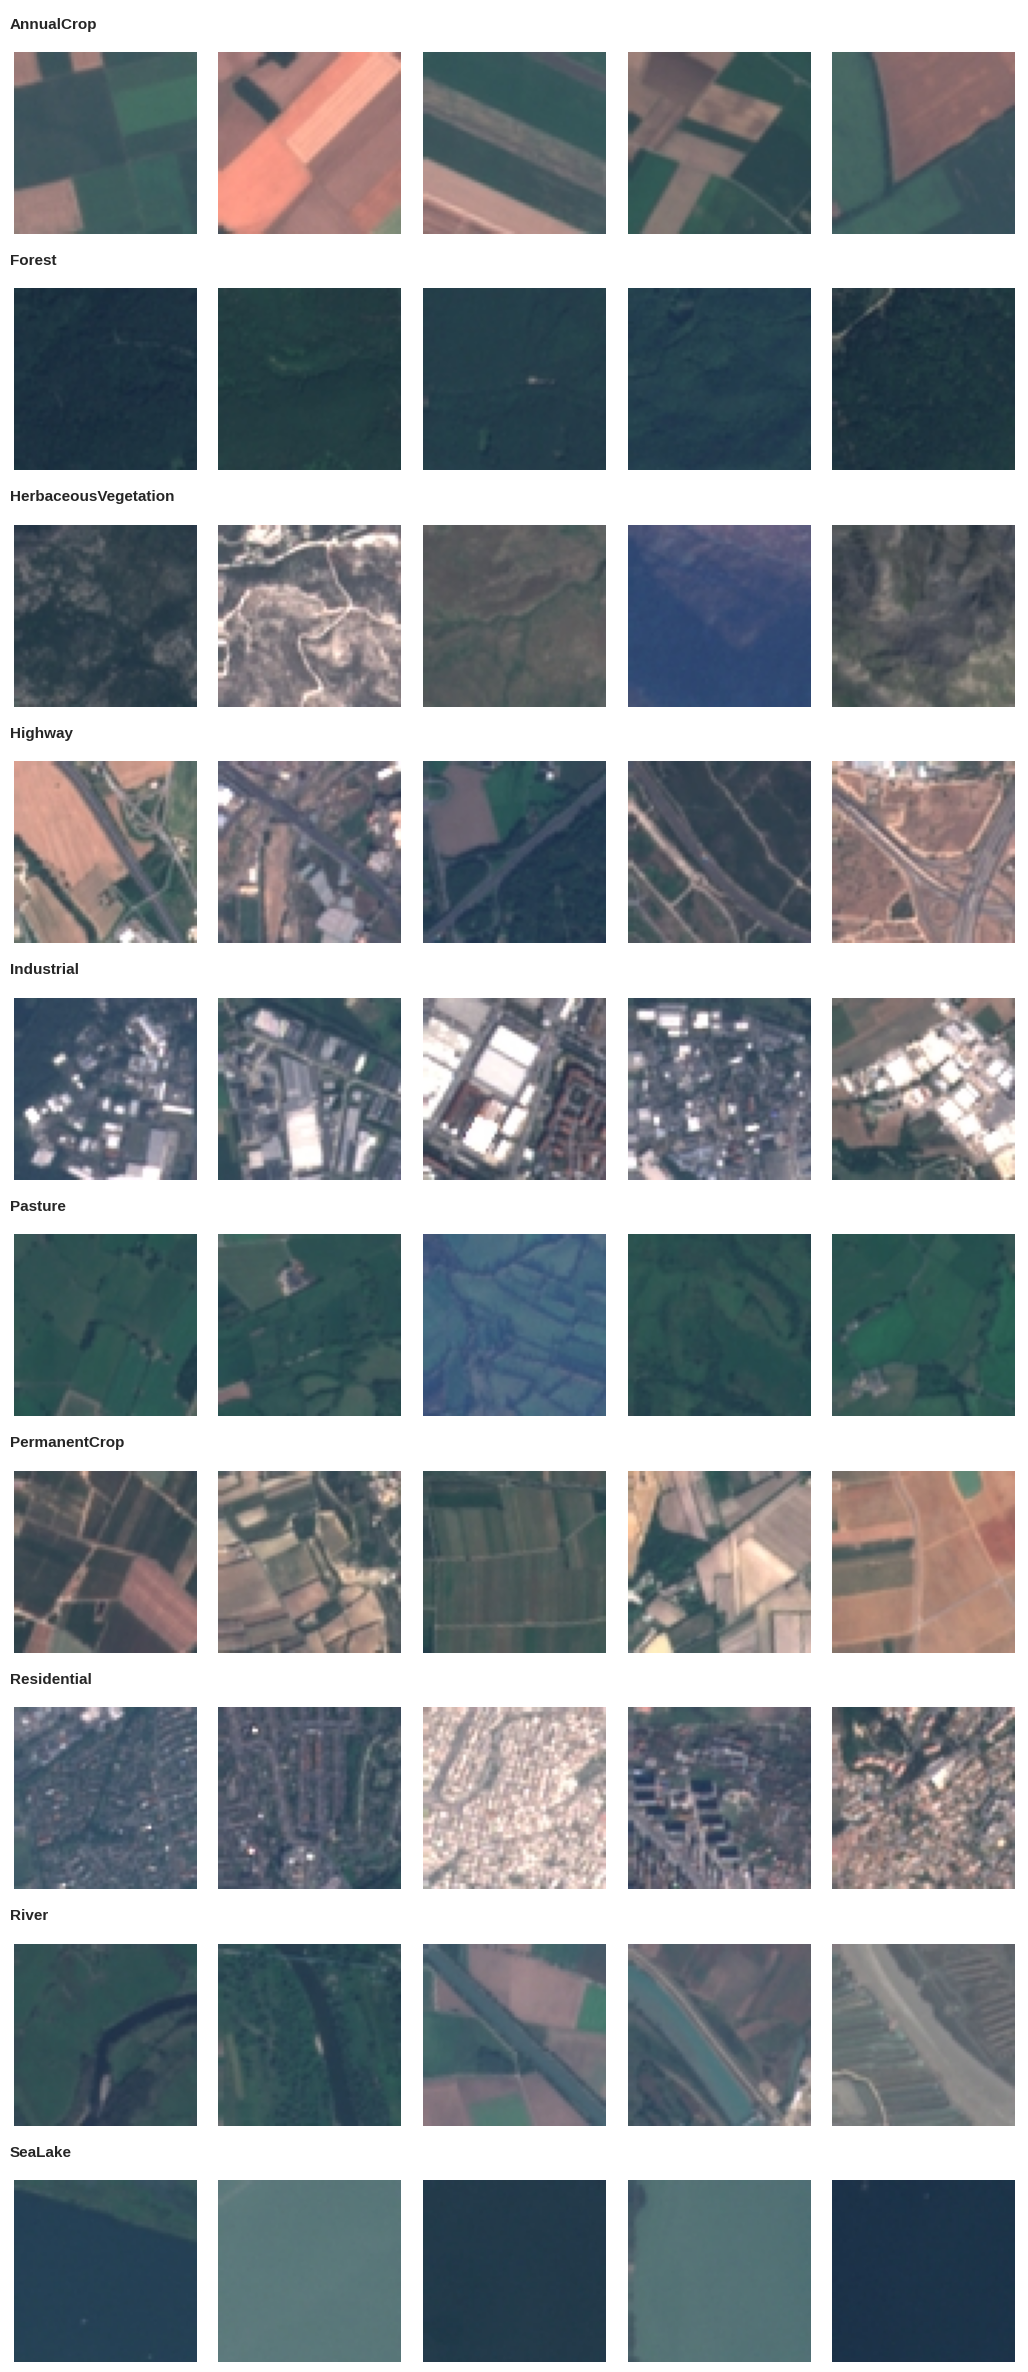

In [17]:
def show_samples_per_class(dataframe, samples_per_class=5):
    sampled = []
    for class_name, group in dataframe.groupby('class'):
        sampled.append(group.sample(min(samples_per_class, len(group)), random_state=RANDOM_STATE))
    sample_df = pd.concat(sampled).reset_index(drop=True)

    class_names = sorted(sample_df['class'].unique())
    n_classes = len(class_names)
    fig = plt.figure(figsize=(samples_per_class * 2.1, n_classes * 2.4))
    height_ratios = [0.16, 1] * n_classes
    grid = fig.add_gridspec(
        nrows=n_classes * 2,
        ncols=samples_per_class,
        height_ratios=height_ratios,
        hspace=0.12,
        wspace=0.08,
    )

    for row_idx, class_name in enumerate(class_names):
        heading_ax = fig.add_subplot(grid[row_idx * 2, :])
        heading_ax.axis('off')
        heading_ax.text(0, 0.5, class_name, fontsize=11, fontweight='bold', va='center')

        class_samples = sample_df[sample_df['class'] == class_name]
        for col_idx in range(samples_per_class):
            ax = fig.add_subplot(grid[row_idx * 2 + 1, col_idx])
            ax.axis('off')
            if col_idx < len(class_samples):
                img = Image.open(class_samples.iloc[col_idx]['path']).convert('RGB')
                ax.imshow(img)

    fig.subplots_adjust(top=0.99, bottom=0.01, left=0.02, right=0.98)
    plt.show()

show_samples_per_class(df, samples_per_class=5)

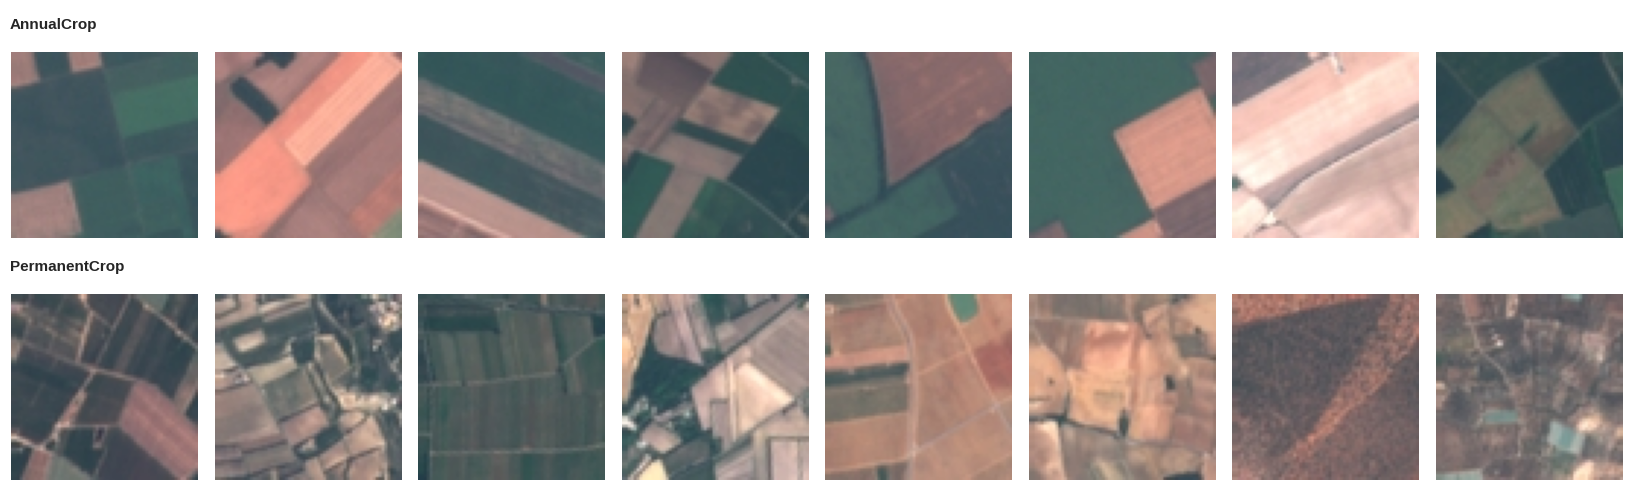

In [18]:
confusing_classes = ['AnnualCrop', 'PermanentCrop']
show_samples_per_class(df[df['class'].isin(confusing_classes)], samples_per_class=8)

## 4. Image Properties

Confirm size is `64 x 64`, channels are RGB, and detect unreadable or corrupted images.

In [19]:
property_records = []
bad_images = []

for path in image_paths:
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            property_records.append({
                'path': path,
                'class': path.parent.name,
                'width': img.width,
                'height': img.height,
                'mode': img.mode,
                'channels': len(img.getbands())
            })
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        bad_images.append({'path': path, 'error': repr(exc)})

props_df = pd.DataFrame(property_records)
bad_df = pd.DataFrame(bad_images)

print(f'Readable images: {len(props_df):,}')
print(f'Unreadable/corrupted images: {len(bad_df):,}')
display(bad_df.head(20))
display(props_df.groupby(['width', 'height', 'mode', 'channels']).size().reset_index(name='count'))

wrong_size = props_df[(props_df['width'] != EXPECTED_SIZE[0]) | (props_df['height'] != EXPECTED_SIZE[1])]
not_rgb = props_df[(props_df['mode'] != 'RGB') | (props_df['channels'] != 3)]
print(f'Images not {EXPECTED_SIZE[0]} x {EXPECTED_SIZE[1]}: {len(wrong_size):,}')
print(f'Images not RGB: {len(not_rgb):,}')

Readable images: 27,000
Unreadable/corrupted images: 0


""


,width,height,mode,channels,count
0,64,64,RGB,3,27000


Images not 64 x 64: 0
Images not RGB: 0


## 5. Pixel Analysis

Calculate mean and standard deviation for red, green, and blue. Plot colour-value distributions. Use these values to normalize images before training.

In [20]:
channel_sum = np.zeros(3, dtype=np.float64)
channel_sq_sum = np.zeros(3, dtype=np.float64)
pixel_count = 0
histograms = np.zeros((3, 256), dtype=np.int64)

for path in props_df['path']:
    arr = np.asarray(Image.open(path).convert('RGB'), dtype=np.float32) / 255.0
    flat = arr.reshape(-1, 3)
    channel_sum += flat.sum(axis=0)
    channel_sq_sum += np.square(flat).sum(axis=0)
    pixel_count += flat.shape[0]

    arr_uint8 = (arr * 255).astype(np.uint8)
    for channel_idx in range(3):
        histograms[channel_idx] += np.bincount(arr_uint8[:, :, channel_idx].ravel(), minlength=256)

channel_mean = channel_sum / pixel_count
channel_std = np.sqrt(channel_sq_sum / pixel_count - np.square(channel_mean))

normalization = pd.DataFrame({
    'channel': ['red', 'green', 'blue'],
    'mean_0_1': channel_mean,
    'std_0_1': channel_std,
    'mean_0_255': channel_mean * 255,
    'std_0_255': channel_std * 255,
})
display(normalization)
print('Use these values during model training:')
print(f'mean = {channel_mean.round(6).tolist()}')
print(f'std = {channel_std.round(6).tolist()}')

,channel,mean_0_1,std_0_1,mean_0_255,std_0_255
0,red,0.344377,0.202657,87.816196,51.677621
1,green,0.380292,0.136891,96.974456,34.907101
2,blue,0.407771,0.115544,103.981632,29.463655


Use these values during model training:
mean = [0.344377, 0.380292, 0.407771]
std = [0.202657, 0.136891, 0.115544]


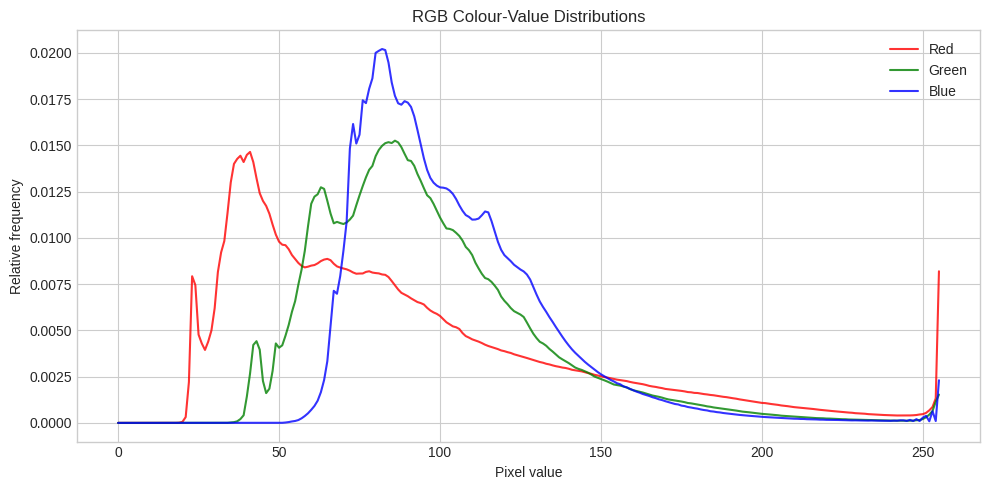

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
for idx, color in enumerate(['red', 'green', 'blue']):
    ax.plot(np.arange(256), histograms[idx] / histograms[idx].sum(), color=color, label=color.capitalize(), alpha=0.8)
ax.set_title('RGB Colour-Value Distributions')
ax.set_xlabel('Pixel value')
ax.set_ylabel('Relative frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Data Quality

Find exact or near-duplicate images. Check unusually dark, bright, blurry, or empty images.

In [22]:
def file_md5(path, chunk_size=1024 * 1024):
    digest = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

def average_hash(path, hash_size=8):
    with Image.open(path).convert('L') as img:
        img = img.resize((hash_size, hash_size), Image.Resampling.LANCZOS)
        arr = np.asarray(img, dtype=np.float32)
    bits = (arr > arr.mean()).astype(np.uint8).ravel().tolist()
    return int(''.join(map(str, bits)), 2)

def hamming_distance(a, b):
    return (a ^ b).bit_count()

md5_to_paths = defaultdict(list)
for path in props_df['path']:
    md5_to_paths[file_md5(path)].append(path)

exact_duplicates_df = pd.DataFrame([
    {'md5': md5, 'count': len(paths), 'paths': paths}
    for md5, paths in md5_to_paths.items()
    if len(paths) > 1
])
print(f'Exact duplicate groups: {len(exact_duplicates_df):,}')
display(exact_duplicates_df.head(20))

Exact duplicate groups: 0


""


In [23]:
class BKTree:
    def __init__(self, distance_func):
        self.distance_func = distance_func
        self.root = None

    def add(self, value):
        if self.root is None:
            self.root = [value, {}]
            return
        node = self.root
        while True:
            distance = self.distance_func(value, node[0])
            children = node[1]
            if distance in children:
                node = children[distance]
            else:
                children[distance] = [value, {}]
                return

    def query(self, value, max_distance):
        if self.root is None:
            return []
        results = []
        stack = [self.root]
        while stack:
            node_value, children = stack.pop()
            distance = self.distance_func(value, node_value)
            if distance <= max_distance:
                results.append((node_value, distance))
            low, high = distance - max_distance, distance + max_distance
            stack.extend(child for child_distance, child in children.items() if low <= child_distance <= high)
        return results

hash_to_paths = defaultdict(list)
for path in props_df['path']:
    hash_to_paths[average_hash(path)].append(path)

near_duplicate_groups = []
tree = BKTree(hamming_distance)
seen_hashes = []
for image_hash, paths in hash_to_paths.items():
    if len(paths) > 1:
        near_duplicate_groups.append({'distance': 0, 'count': len(paths), 'paths': paths})
    for matched_hash, distance in tree.query(image_hash, max_distance=5):
        near_duplicate_groups.append({
            'distance': distance,
            'count': len(paths) + len(hash_to_paths[matched_hash]),
            'paths': paths + hash_to_paths[matched_hash],
        })
    tree.add(image_hash)
    seen_hashes.append(image_hash)

near_duplicates_df = pd.DataFrame(near_duplicate_groups)
if not near_duplicates_df.empty:
    near_duplicates_df = near_duplicates_df.sort_values(['distance', 'count'], ascending=[True, False])
print(f'Near duplicate candidate groups with average-hash distance <= 5: {len(near_duplicates_df):,}')
display(near_duplicates_df.head(20))

Near duplicate candidate groups with average-hash distance <= 5: 16,395


,distance,count,paths
2832,0,165,[/home/pannatat/personal/eurosat-multispectral...
3721,0,7,[/home/pannatat/personal/eurosat-multispectral...
3155,0,5,[/home/pannatat/personal/eurosat-multispectral...
4729,0,5,[/home/pannatat/personal/eurosat-multispectral...
28,0,4,[/home/pannatat/personal/eurosat-multispectral...
3,0,3,[/home/pannatat/personal/eurosat-multispectral...
2859,0,3,[/home/pannatat/personal/eurosat-multispectral...
4057,0,3,[/home/pannatat/personal/eurosat-multispectral...
4477,0,3,[/home/pannatat/personal/eurosat-multispectral...
4,0,2,[/home/pannatat/personal/eurosat-multispectral...


In [24]:
quality_records = []
for path in props_df['path']:
    img = Image.open(path).convert('RGB')
    arr = np.asarray(img, dtype=np.float32)
    gray = np.asarray(img.convert('L'), dtype=np.float32)
    edges = np.asarray(img.convert('L').filter(ImageFilter.FIND_EDGES), dtype=np.float32)
    quality_records.append({
        'path': path,
        'class': path.parent.name,
        'mean_brightness': gray.mean(),
        'std_brightness': gray.std(),
        'edge_mean': edges.mean(),
        'rgb_std': arr.reshape(-1, 3).std(axis=0).mean(),
    })

quality_df = pd.DataFrame(quality_records)
quality_df['is_unusually_dark'] = quality_df['mean_brightness'] <= quality_df['mean_brightness'].quantile(0.01)
quality_df['is_unusually_bright'] = quality_df['mean_brightness'] >= quality_df['mean_brightness'].quantile(0.99)
quality_df['is_potentially_blurry'] = quality_df['edge_mean'] <= quality_df['edge_mean'].quantile(0.01)
quality_df['is_low_information_or_empty'] = quality_df['std_brightness'] <= quality_df['std_brightness'].quantile(0.01)

flags = ['is_unusually_dark', 'is_unusually_bright', 'is_potentially_blurry', 'is_low_information_or_empty']
display(quality_df[flags].sum().to_frame('count'))
display(quality_df[quality_df[flags].any(axis=1)].head(30))

,count
is_unusually_dark,270
is_unusually_bright,270
is_potentially_blurry,270
is_low_information_or_empty,270


,path,class,mean_brightness,std_brightness,edge_mean,rgb_std,is_unusually_dark,is_unusually_bright,is_potentially_blurry,is_low_information_or_empty
39,/home/pannatat/personal/eurosat-multispectral-...,AnnualCrop,196.890381,24.559736,19.692383,24.923250,False,True,False,False
128,/home/pannatat/personal/eurosat-multispectral-...,AnnualCrop,183.128662,33.605633,21.147461,32.023037,False,True,False,False
138,/home/pannatat/personal/eurosat-multispectral-...,AnnualCrop,196.583740,15.119764,17.694580,13.944263,False,True,False,False
175,/home/pannatat/personal/eurosat-multispectral-...,AnnualCrop,194.428711,31.558443,29.267334,30.850756,False,True,False,False
314,/home/pannatat/personal/eurosat-multispectral-...,AnnualCrop,208.970947,14.350127,18.565430,13.396510,False,True,False,False
357,/home/pannatat/personal/eurosat-multispectral-...,AnnualCrop,190.946533,28.865965,22.700195,29.084396,False,True,False,False
416,/home/pannatat/personal/eurosat-multispectral-...,AnnualCrop,190.673828,28.575413,24.413574,28.102850,False,True,False,False
578,/home/pannatat/personal/eurosat-multispectral-...,AnnualCrop,187.536377,13.290572,17.273682,12.958836,False,True,False,False
618,/home/pannatat/personal/eurosat-multispectral-...,AnnualCrop,187.537842,28.475182,19.218750,26.960283,False,True,False,False
630,/home/pannatat/personal/eurosat-multispectral-...,AnnualCrop,209.896240,20.150585,20.527832,20.766047,False,True,False,False


## Notes for Training

- Use the RGB `mean` and `std` values from the pixel analysis section to normalize image tensors.
- Use the saved stratified split CSV to avoid leakage between training, validation, and test sets.
- Review duplicate and quality candidate tables before deleting or excluding any images.